In [2]:
# %% SCRIPT TO RUN THE MODEL
# Import matplotlib to generate figures
import matplotlib.pyplot as plt
# This is an example script that runs
# the ecohydrology model.
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel

## Import packages
## We need to add the module path to our system path so 
## so that our notebook can find our local objects and code:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
     
import numpy as np
import pandas as pd

import matplotlib.patches as mpatches

from math import exp
import seaborn as sns

import glob
from dateutil.relativedelta import *
from numpy.random import exponential, uniform
import scipy.stats as st
from statistics import mean 

# Import objects

from farm.functions import *
from farm.climate import make_climate_parameters, check_exponential, Climate

# Set background color
plot.rc['figure.facecolor'] = 'white'
plot.rc.axesfacecolor = 'white'

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


#### Here I run the model from `runmodel.py`

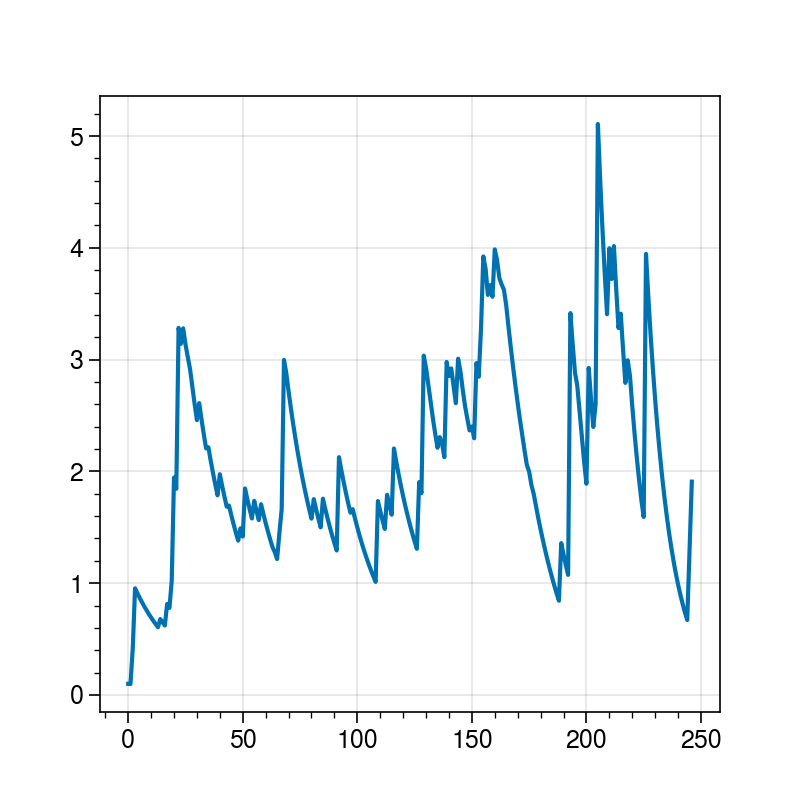

In [6]:
# %% Initialize Climate
climate = Climate()

# %% Initialize Soil
soil = Soil(texture='loam')

# %% Initialize Plant
crop = Crop(soil=soil)

# Finally, now that the plant is defined, we need
# to set the soil.nZr property:
soil.set_nZr(crop)

# %% Initialize the Model
model = CropModel(crop=crop, climate=climate, soil=soil)

# %% Run the Model
model.run()

# %% Assign Model Output
output = model.output()

# %% Generate figures
output['ET'].plot()

plt.show()


#### Here I run the model for a yield estimate (remaking figure 8 kind of)

In [5]:
# Import the simulations

n_sim = 10000
no_sims = np.arange(0,n_sim)

files = glob.glob('../data/Output/*.csv')

output = []
for f, n in zip(files, no_sims):
    f_ = pd.read_csv(f).drop('Unnamed: 0',axis=1)
    output.append(f_)
    
# Will need average s for Fig. 6
pd_sim = 60 # planting date
lgp = 180 # length of growing period
end = pd_sim + lgp
avg_s = [df[pd_sim:end]['s'].mean() for df in output]

In [8]:
# Set OL JOGI climatology for the following figures
station = 'OL JOGI FARM'
interval='dekad'
data_file="data/CETRAD/CETRAD_rainfall.csv"
texture='clay loam'

a_mid, l_mid, sd = make_climate_parameters(data_file = data_file, station=station, interval=interval) 

# Make a dataframe with these alphas and lambdas
df_mid = pd.DataFrame({'alpha':a_mid, 'lambda':l_mid, 'dekad':np.arange(1,38,1),'doy':['10','20','30','40',
                                                                           '50','60','70','80','90','100',
                                                                            '110','120','130','140','150','160',
                                                                             '170','180','190','200','210','220',
                                                                             '230','240','250','260','270','280','290',
                                                                              '300','310','320','330','340','350','360','365'
                                                                              ]})
climate = Climate(
        data_file=data_file,
        station=station,
        interval=interval,
        alpha_r = a_mid,
        lambda_r = l_mid,
        do_std=False)
    
soil = Soil(texture)
crop = Crop(soil=soil)
soil.set_nZr(crop)  
model = CropModel(crop=crop,soil=soil,climate=climate)

model.run()

# Set saturation variable
s = np.arange(0, 1, 0.0056) #saturation

# Convert to vwc
vwc = s*Soil(texture).n 


Laikipia station data was inputted.


In [9]:
## Figure 8. Dynamic Stress-Rainfall-Yield Relationship

# Line up the data
data = [crop.calc_dstress(s=df.s, stress=df.stress, Y_MAX = evolved_calc_yield(dtm=lgp)) for df in output]
rf = [df['R'].sum() for df in output]
    
# Turn dynamic water stress data into a tuple
df = pd.DataFrame.from_records(data, columns =['AvgStress2','DynamicStress','Yield'])
df['RF'] = rf
print(max(df.Yield))

# Dynamic Stress Yield Rlxn

def fig8(df=None):
    # We'll be using these variables a lot
    x = df.RF
    y = df.Yield

    # Y axis can either be nornalized yield or yield
    df['Yield_norm'] = df.Yield/max(df.Yield)

    f, axs = plot.subplots(journal='agu2')
    axs.format(
        abc=False, abcloc='ul', suptitle='Seasonal Rainfall-Yield Relationship')
    
    cols = 'dark'
    
    plt.scatter(df.RF, df.Yield_norm, alpha=0.6, size=2.5)
    plt.ylim(-.05,1.05)
    plt.ylabel('Normalized yield, $Y/Y_{max}$ ') # Yield normalized by max. yield
    plt.xlabel('Seasonal rainfall [mm]')
    
    axs.tick_params(axis='y', colors=cols)
    axs.tick_params(axis='x', colors=cols)
    
fig8(df=df)

ValueError: max() arg is an empty sequence

In [10]:
print("len(output):", len(output))

# check each season df has what you think
print("first keys/cols:", list(output[0].columns) if len(output) else None)

# rf calculation sanity
rf = [season['R'].sum() for season in output]
print("len(rf):", len(rf), "rf sample:", rf[:5])

# calc_dstress results sanity
data = [crop.calc_dstress(s=season.s, stress=season.stress, Y_MAX=evolved_calc_yield(dtm=lgp))
        for season in output]
print("len(data):", len(data), "data sample:", data[:3])


len(output): 0
first keys/cols: None
len(rf): 0 rf sample: []
len(data): 0 data sample: []


In [ ]:
def calc_yield(stress=None, max_yield = 4680):
    yield_kg_ha = -max_yield*stress + max_yield
    
    if stress > 1:
        raise ValueError("static stress, {stress} is larger than 1".format(
                stress=stress))
    if stress < 0:
        raise ValueError("static stress, {stress} is less than 0".format(
                stress=stress))
    
    return yield_kg_ha

Stress: 0.85
Yield: 720 kg/ha


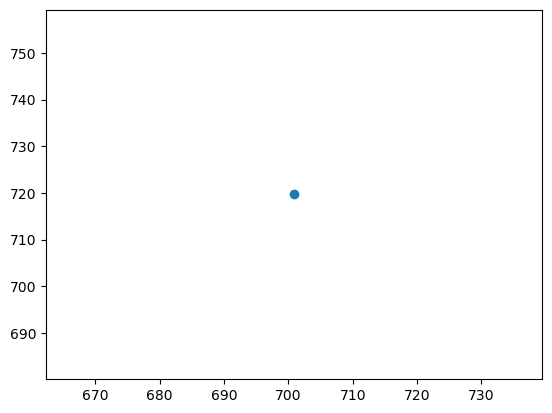

In [ ]:
T_actual = output['T'].sum()
T_potential = output['kc'].max() * climate.ET_max * len(output)

stress = 1 - (T_actual / T_potential)
stress = max(0, min(1, stress))  

yield_kg_ha = calc_yield(stress)

print(f"Stress: {stress:.2f}")
print(f"Yield: {yield_kg_ha:.0f} kg/ha")

seasonal_rain = output['R'].sum()  # mm over the season
plt.scatter(seasonal_rain, yield_kg_ha)

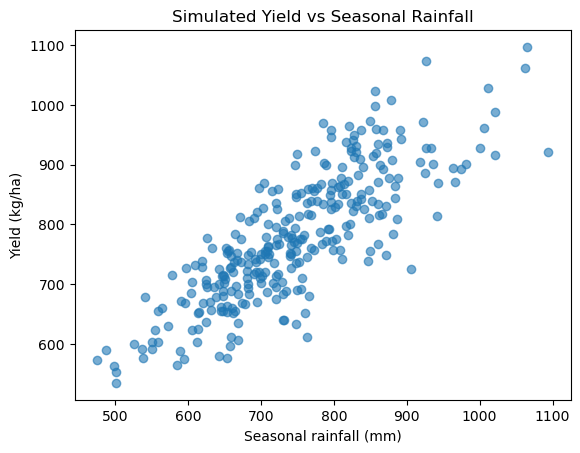

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from farm import Climate, Soil, Crop, CropModel

def calc_yield(stress, max_yield=4680):
    if not (0 <= stress <= 1):
        raise ValueError("stress must be in [0,1]")
    return max_yield * (1 - stress)

def run_one_season(seed=None, texture="loam",
                   alpha_r=10.0, lambda_r=0.3, t_seas=180, ET_max=6.5):
    if seed is not None:
        np.random.seed(seed)

    climate = Climate(alpha_r=alpha_r, lambda_r=lambda_r, t_seas=t_seas, ET_max=ET_max)
    soil = Soil(texture=texture)
    crop = Crop(soil=soil)
    soil.set_nZr(crop)

    model = CropModel(crop=crop, climate=climate, soil=soil)
    model.run()
    output = model.output()

    # Seasonal totals
    seasonal_rain = float(output["R"].sum())          # mm
    T_actual = float(output["T"].sum())               # mm

    T_potential = float(output["kc"].max() * climate.ET_max * len(output))

    stress = 1 - (T_actual / T_potential) if T_potential > 0 else 1.0
    stress = max(0.0, min(1.0, stress))

    y = float(calc_yield(stress))                     # kg/ha
    return seasonal_rain, y, stress

# Run
N = 300 
rows = []
for i in range(N):
    rain, yld, stress = run_one_season(seed=i)  
    rows.append({"seasonal_rain_mm": rain, "yield_kg_ha": yld, "stress": stress})

df = pd.DataFrame(rows)

# plot
plt.figure()
plt.scatter(df["seasonal_rain_mm"], df["yield_kg_ha"], alpha=0.6)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Yield (kg/ha)")
plt.title("Simulated Yield vs Seasonal Rainfall")
plt.show()


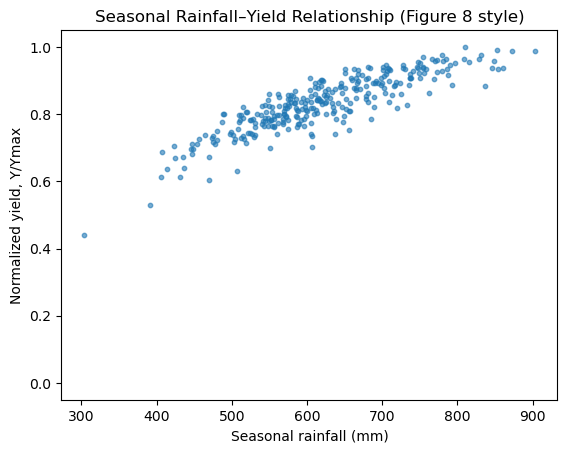

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evolved_calc_yield(dtm=120, m=None, b=None):
    # Simple fallback if you don't have the repo's regression loaded
    # Replace with the repo’s evolved_calc_yield if you want the exact calibration
    Y_MAX = 4680  # kg/ha
    return Y_MAX

def dynamic_stress_to_yield(output_df, Y_MAX):
    """
    Figure-8 style: use *dynamic* (time-varying) stress from the model output.
    Here we summarize it as the seasonal mean stress, then convert to yield.
    """
    dyn_stress = float(np.mean(output_df["stress"]))  # stress in [0,1]
    dyn_stress = max(0.0, min(1.0, dyn_stress))
    y = Y_MAX * (1 - dyn_stress)
    return dyn_stress, y

from farm import Climate, Soil, Crop, CropModel

N = 300
lgp = 120  # pick a days-to-maturity / length-of-growing-period you want
Y_MAX = evolved_calc_yield(dtm=lgp)

rows = []
for seed in range(N):
    np.random.seed(seed)  # reproducible stochastic rainfall

    climate = Climate()              # or set alpha_r/lambda_r/t_seas/ET_max
    soil = Soil(texture="loam")
    crop = Crop(soil=soil)
    soil.set_nZr(crop)

    model = CropModel(crop=crop, climate=climate, soil=soil)
    model.run()
    out = model.output()             # DataFrame with 'stress' and 'R'

    RF = float(out["R"].sum())       # seasonal rainfall (mm)
    dyn_stress, y = dynamic_stress_to_yield(out, Y_MAX)

    rows.append({"RF": RF, "Yield": y, "DynamicStress": dyn_stress})

df = pd.DataFrame(rows)
df["Yield_norm"] = df["Yield"] / df["Yield"].max()

plt.figure()
plt.scatter(df["RF"], df["Yield_norm"], alpha=0.6, s=10)
plt.ylim(-0.05, 1.05)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Normalized yield, Y/Ymax")
plt.title("Seasonal Rainfall–Yield Relationship (Figure 8 style)")
plt.show()
